# 🌱 Диагностика модели классификации почвы

Этот notebook проверяет работоспособность обученной модели и выявляет возможные проблемы.

In [1]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import os
import json
import matplotlib.pyplot as plt
import numpy as np

print('✓ Библиотеки импортированы')

✓ Библиотеки импортированы


## 1. Проверка наличия файлов модели

In [2]:
print("="*50)
print("ПРОВЕРКА ФАЙЛОВ")
print("="*50)

model_path = "models/soil_classifier_best.pth"
classes_path = "models/classes.json"

if os.path.exists(model_path):
    size_mb = os.path.getsize(model_path) / (1024 * 1024)
    print(f"✓ Модель найдена: {model_path} ({size_mb:.2f} MB)")
else:
    print(f"✗ Модель НЕ найдена: {model_path}")

if os.path.exists(classes_path):
    print(f"✓ Классы найдены: {classes_path}")
    with open(classes_path, 'r') as f:
        classes = json.load(f)
    print(f"Классы: {classes}")
else:
    print(f"✗ Классы НЕ найдены: {classes_path}")
    classes = ["Black_Soil", "Clay", "Loam", "Sand"]

ПРОВЕРКА ФАЙЛОВ
✓ Модель найдена: models/soil_classifier_best.pth (8.74 MB)
✓ Классы найдены: models/classes.json
Классы: ['Black_Soil', 'Clay', 'Loam', 'Sand']


## 2. Загрузка модели

In [3]:
print("="*50)
print("ЗАГРУЗКА МОДЕЛИ")
print("="*50)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Устройство: {device}")

# Создаём архитектуру
model = models.mobilenet_v2(pretrained=False)
print(f"✓ Архитектура MobileNetV2 создана")
print(f"last_channel: {model.last_channel}")

# Модифицируем последний слой
model.classifier[1] = nn.Linear(model.last_channel, len(classes))
print(f"✓ Последний слой изменён на {len(classes)} классов")

# Загружаем веса
if os.path.exists(model_path):
    state_dict = torch.load(model_path, map_location=device)
    model.load_state_dict(state_dict)
    print(f"✓ Веса модели загружены успешно")
else:
    print(f"✗ Не удалось загрузить веса")

model = model.to(device)
model.eval()
print(f"✓ Модель переведена в режим оценки")

ЗАГРУЗКА МОДЕЛИ
Устройство: cpu


C:\Users\Шерзод.DESKTOP-SO3T8TL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\Шерзод.DESKTOP-SO3T8TL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


✓ Архитектура MobileNetV2 создана
last_channel: 1280
✓ Последний слой изменён на 4 классов
✓ Веса модели загружены успешно
✓ Модель переведена в режим оценки


## 3. Тест на случайных данных

In [4]:
print("="*50)
print("ТЕСТ НА СЛУЧАЙНЫХ ДАННЫХ")
print("="*50)

# Создаём случайный тензор
dummy_input = torch.randn(1, 3, 224, 224).to(device)

with torch.no_grad():
    output = model(dummy_input)
    probabilities = torch.nn.functional.softmax(output[0], dim=0)
    confidence, index = torch.max(probabilities, 0)

predicted_class = classes[index.item()]
print(f"✓ Инференс работает!")
print(f"Предсказанный класс: {predicted_class}")
print(f"Уверенность: {confidence.item():.4f}")
print(f"\nВсе вероятности:")
for i, (cls, prob) in enumerate(zip(classes, probabilities.tolist())):
    print(f"  {cls}: {prob:.4f}")

ТЕСТ НА СЛУЧАЙНЫХ ДАННЫХ
✓ Инференс работает!
Предсказанный класс: Black_Soil
Уверенность: 0.9782

Все вероятности:
  Black_Soil: 0.9782
  Clay: 0.0043
  Loam: 0.0088
  Sand: 0.0087


## 4. Тест на реальных изображениях

In [5]:
print("="*50)
print("ТЕСТ НА РЕАЛЬНЫХ ИЗОБРАЖЕНИЯХ")
print("="*50)

# Ищем тестовые изображения
test_images = []
for root, dirs, files in os.walk("data/train"):
    for file in files:
        if file.endswith(('.jpg', '.jpeg', '.png')):
            test_images.append(os.path.join(root, file))
            if len(test_images) >= 6:
                break
    if len(test_images) >= 6:
        break

print(f"Найдено {len(test_images)} тестовых изображений\n")

# Трансформации
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Тестируем
results = []
for img_path in test_images[:6]:
    image = Image.open(img_path).convert('RGB')
    img_t = transform(image)
    batch_t = torch.unsqueeze(img_t, 0).to(device)
    
    with torch.no_grad():
        output = model(batch_t)
        probabilities = torch.nn.functional.softmax(output[0], dim=0)
        confidence, index = torch.max(probabilities, 0)
    
    predicted = classes[index.item()]
    actual = os.path.basename(os.path.dirname(img_path))
    correct = predicted == actual
    
    results.append({
        'image': image,
        'path': img_path,
        'actual': actual,
        'predicted': predicted,
        'confidence': confidence.item(),
        'correct': correct,
        'probabilities': probabilities.cpu().numpy()
    })
    
    status = "✓ ПРАВИЛЬНО" if correct else "✗ НЕПРАВИЛЬНО"
    print(f"Файл: {os.path.basename(img_path)}")
    print(f"  Реальный: {actual}")
    print(f"  Предсказанный: {predicted}")
    print(f"  Уверенность: {confidence.item():.2%}")
    print(f"  {status}\n")

ТЕСТ НА РЕАЛЬНЫХ ИЗОБРАЖЕНИЯХ
Найдено 6 тестовых изображений

Файл: dummy_0.jpg
  Реальный: Black_Soil
  Предсказанный: Black_Soil
  Уверенность: 92.61%
  ✓ ПРАВИЛЬНО

Файл: dummy_1.jpg
  Реальный: Black_Soil
  Предсказанный: Black_Soil
  Уверенность: 93.58%
  ✓ ПРАВИЛЬНО

Файл: dummy_10.jpg
  Реальный: Black_Soil
  Предсказанный: Black_Soil
  Уверенность: 91.87%
  ✓ ПРАВИЛЬНО

Файл: dummy_11.jpg
  Реальный: Black_Soil
  Предсказанный: Black_Soil
  Уверенность: 88.18%
  ✓ ПРАВИЛЬНО

Файл: dummy_12.jpg
  Реальный: Black_Soil
  Предсказанный: Black_Soil
  Уверенность: 91.50%
  ✓ ПРАВИЛЬНО

Файл: dummy_13.jpg
  Реальный: Black_Soil
  Предсказанный: Black_Soil
  Уверенность: 73.86%
  ✓ ПРАВИЛЬНО



## 5. Визуализация результатов

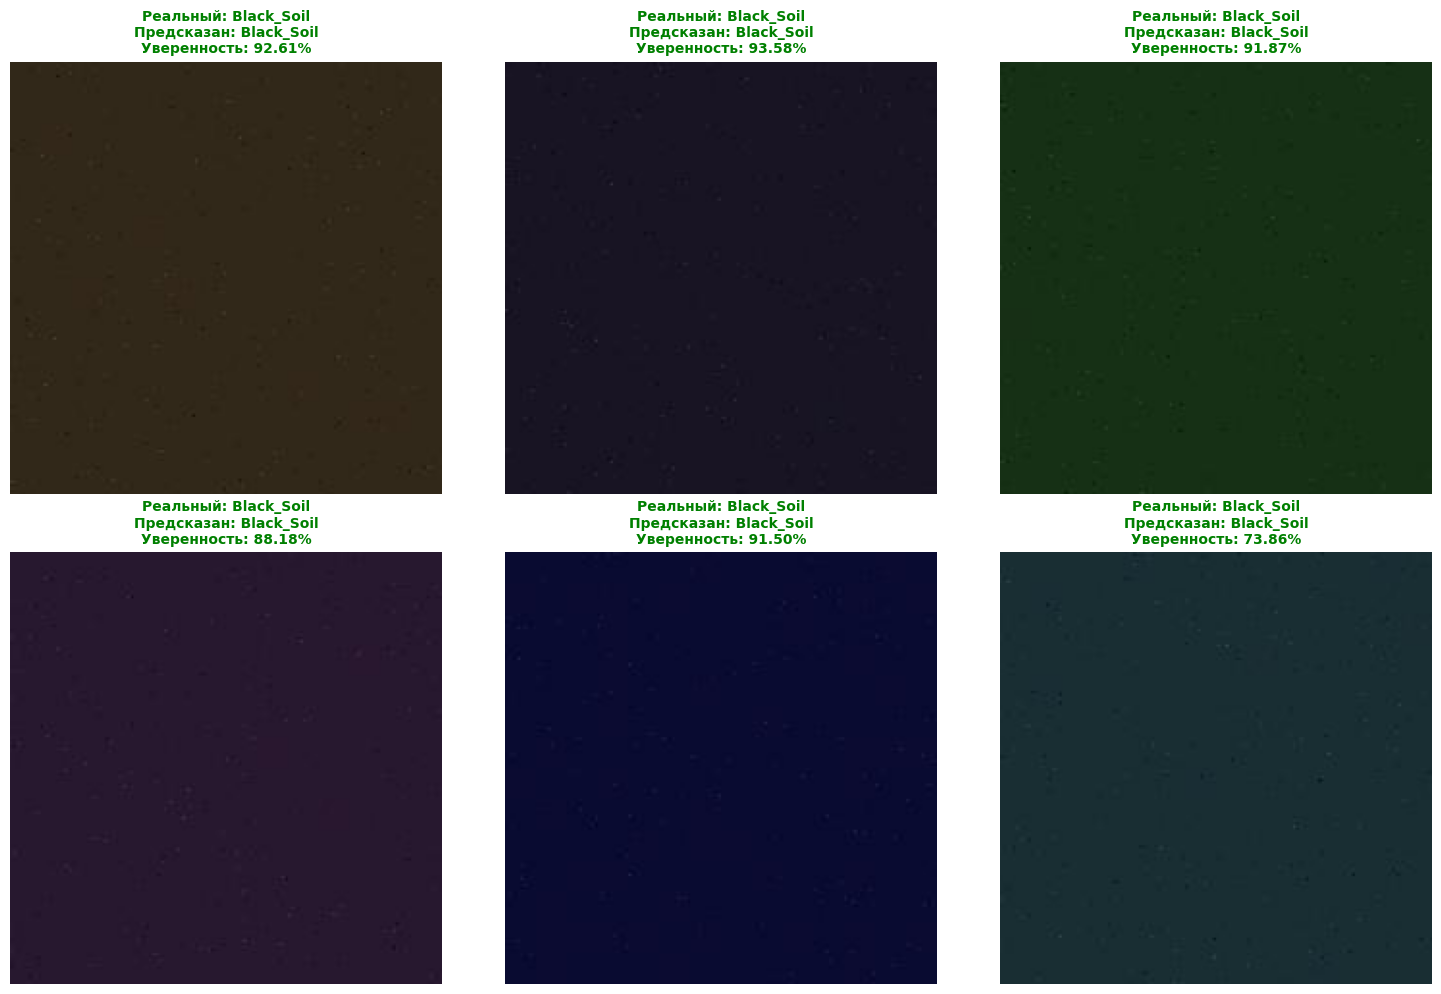


СТАТИСТИКА
Правильных предсказаний: 6/6
Точность: 100.00%


In [6]:
# Визуализируем результаты
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, result in enumerate(results[:6]):
    ax = axes[idx]
    ax.imshow(result['image'])
    
    color = 'green' if result['correct'] else 'red'
    title = f"Реальный: {result['actual']}\n"
    title += f"Предсказан: {result['predicted']}\n"
    title += f"Уверенность: {result['confidence']:.2%}"
    
    ax.set_title(title, color=color, fontsize=10, weight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

# Статистика
correct_count = sum(1 for r in results if r['correct'])
total_count = len(results)
accuracy = correct_count / total_count if total_count > 0 else 0

print(f"\n{'='*50}")
print(f"СТАТИСТИКА")
print(f"{'='*50}")
print(f"Правильных предсказаний: {correct_count}/{total_count}")
print(f"Точность: {accuracy:.2%}")

## 6. Анализ вероятностей

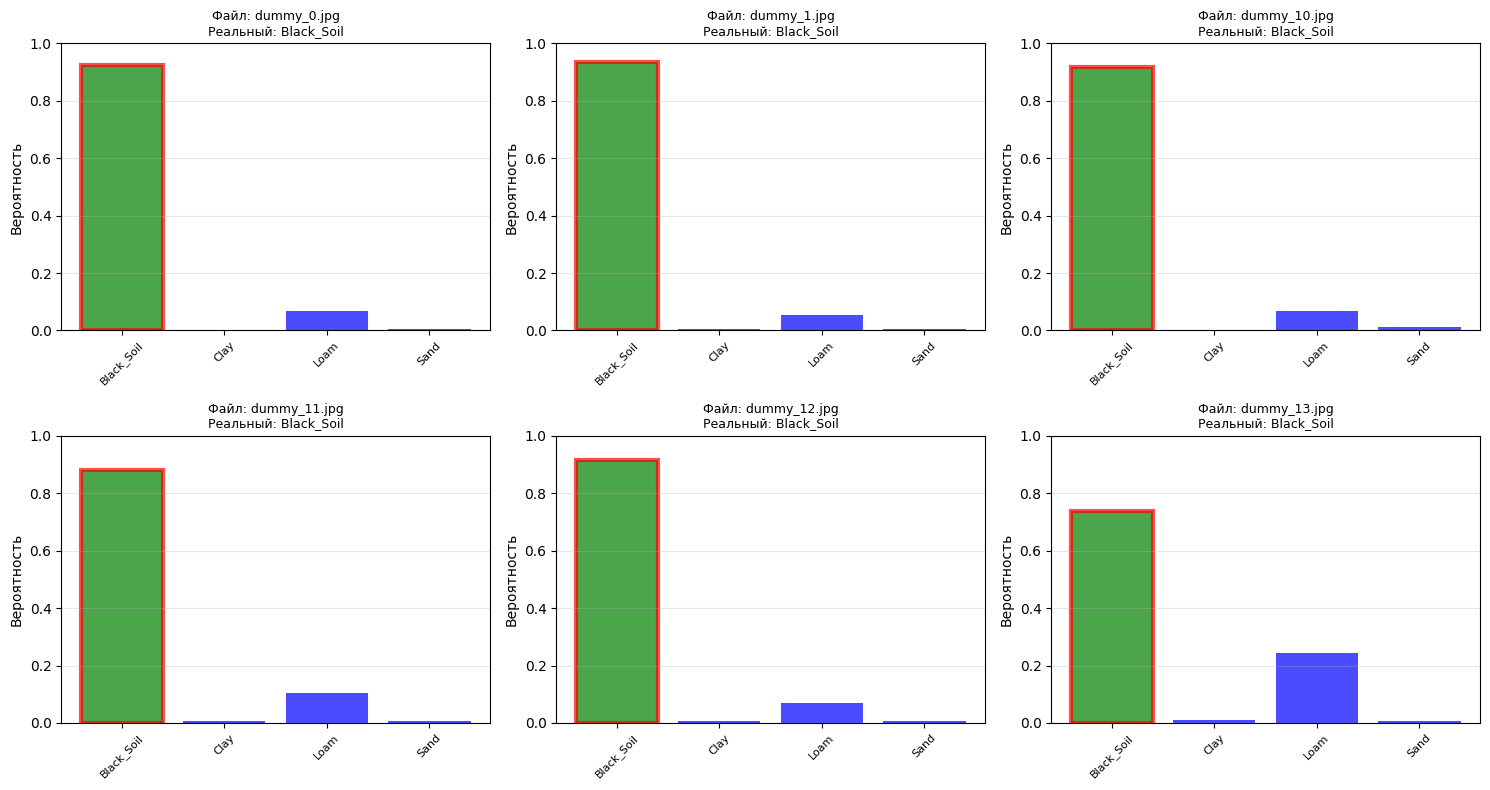

In [7]:
# График вероятностей для каждого изображения
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, result in enumerate(results[:6]):
    ax = axes[idx]
    probs = result['probabilities']
    
    colors = ['green' if cls == result['actual'] else 'blue' for cls in classes]
    bars = ax.bar(classes, probs, color=colors, alpha=0.7)
    
    # Подсвечиваем предсказанный класс
    predicted_idx = classes.index(result['predicted'])
    bars[predicted_idx].set_edgecolor('red')
    bars[predicted_idx].set_linewidth(3)
    
    ax.set_title(f"Файл: {os.path.basename(result['path'])}\nРеальный: {result['actual']}", fontsize=9)
    ax.set_ylabel('Вероятность')
    ax.set_ylim([0, 1])
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Тест через класс SoilClassifier

ТЕСТ ЧЕРЕЗ КЛАСС SoilClassifier
Model loaded from models/soil_classifier_best.pth
✓ Классификатор загружен

Предсказание: Black_Soil
Уверенность: 92.61%

Плодородность: Высокое (High)
Описание: Темный, рыхлый грунт. Богатый гумусом.
Визуальные характеристики: Темный цвет, рыхлая структура

Рекомендуемые культуры:
  - Пшеница (Wheat)
  - Овощи (Vegetables)
  - Подсолнечник (Sunflower)
  - Кукуруза (Corn)


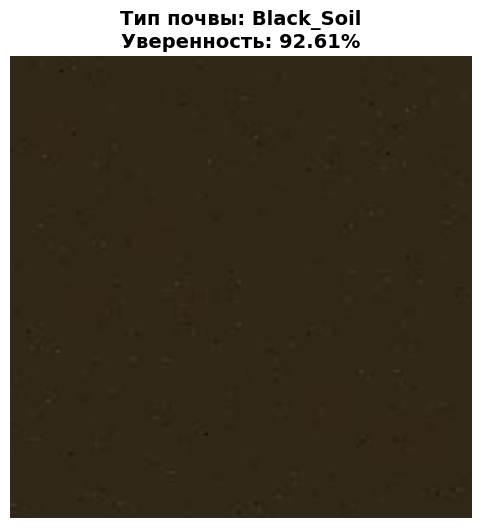

In [8]:
print("="*50)
print("ТЕСТ ЧЕРЕЗ КЛАСС SoilClassifier")
print("="*50)

import sys
sys.path.append('..')

from src.inference import SoilClassifier
from src.recommendations import get_soil_info

# Загружаем классификатор
classifier = SoilClassifier(
    model_path="models/soil_classifier_best.pth",
    classes_path="models/classes.json"
)

print("✓ Классификатор загружен\n")

# Тестируем на первом изображении
if test_images:
    test_img = Image.open(test_images[0]).convert('RGB')
    soil_type, confidence = classifier.predict(test_img)
    
    print(f"Предсказание: {soil_type}")
    print(f"Уверенность: {confidence:.2%}\n")
    
    # Получаем рекомендации
    info = get_soil_info(soil_type)
    print(f"Плодородность: {info['fertility']}")
    print(f"Описание: {info['description']}")
    print(f"Визуальные характеристики: {info['visual_characteristics']}")
    print(f"\nРекомендуемые культуры:")
    for crop in info['crops']:
        print(f"  - {crop}")
    
    # Визуализация
    plt.figure(figsize=(8, 6))
    plt.imshow(test_img)
    plt.title(f"Тип почвы: {soil_type}\nУверенность: {confidence:.2%}", fontsize=14, weight='bold')
    plt.axis('off')
    plt.show()

## 8. Выводы

После выполнения всех тестов вы можете сделать выводы:

1. **Модель загружается?** - Проверьте раздел 2
2. **Инференс работает?** - Проверьте раздел 3
3. **Точность на реальных данных?** - Проверьте раздел 5
4. **Уверенность модели?** - Проверьте раздел 6
5. **API работает?** - Проверьте раздел 7

### Возможные проблемы:

- **Низкая точность**: Модель нужно дообучить или использовать больше данных
- **Низкая уверенность**: Модель не уверена в предсказаниях (все вероятности близки)
- **Ошибки загрузки**: Проверьте пути к файлам модели
- **Всегда один класс**: Модель переобучена или данные несбалансированы